<a href="https://colab.research.google.com/github/Shashank18ram/Data-Science-Ml/blob/main/Anime_CSR_Assignment%5B18%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Recommendation System – Anime Dataset



## 1. Import Libraries and Load the Dataset

In [1]:
import warnings
warnings.filterwarnings("ignore")

import html
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MultiLabelBinarizer
from sklearn.metrics.pairwise import cosine_similarity

# Load the supplied dataset
df = pd.read_csv("anime.csv")

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (12294, 7)


,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


## 2. Explore the Dataset

I first inspect the data types, summary statistics, missing values and duplicate records.

The dataset has 12,294 rows and 7 columns. The target for recommendation is not a single class label; instead, each anime is represented by its content and numerical attributes, and cosine similarity is used to find similar items.


In [2]:
print("Columns:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("Data Type"))

print("\nSummary statistics:")
display(df.describe(include="all").T)

print("\nMissing values:")
missing = pd.DataFrame({
    "Missing Count": df.isna().sum(),
    "Missing Percentage": (df.isna().mean() * 100).round(2)
})
display(missing)

print("Duplicate rows:", df.duplicated().sum())
print("Duplicate anime IDs:", df["anime_id"].duplicated().sum())


Columns:
['anime_id', 'name', 'genre', 'type', 'episodes', 'rating', 'members']

Data types:


,Data Type
anime_id,int64
name,object
genre,object
type,object
episodes,object
rating,float64
members,int64



Summary statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
anime_id,12294.0,NaN,NaN,NaN,14058.221653,11455.294701,1.0,3484.25,10260.5,24794.5,34527.0
name,12294,12292,Saru Kani Gassen,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
genre,12232,3264,Hentai,823,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,12269,6,TV,3787,NaN,NaN,NaN,NaN,NaN,NaN,NaN
episodes,12294,187,1,5677,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rating,12064.0,NaN,NaN,NaN,6.473902,1.026746,1.67,5.88,6.57,7.18,10.0
members,12294.0,NaN,NaN,NaN,18071.338864,54820.676925,5.0,225.0,1550.0,9437.0,1013917.0



Missing values:


,Missing Count,Missing Percentage
anime_id,0,0.00
name,0,0.00
genre,62,0.50
type,25,0.20
episodes,0,0.00
rating,230,1.87
members,0,0.00


Duplicate rows: 0
Duplicate anime IDs: 0


## 3. Data Preprocessing

### Missing values

The dataset contains missing values in `genre`, `type` and `rating`.

I handle them as follows:
- Missing genre Unknown
- Missing type Unknown
- Missing rating  median rating

The title and ID are not imputed because they are identifiers/text fields.

### Cleaning text

Some anime names contain HTML entities such as `&#039;`. I decode these entities so that titles are displayed normally.

### Episodes

The episodes column contains values such as numeric episode counts and Unknown`. I convert it to a numeric column and treat `"Unknown"` as missing. The median number of episodes is then used for the numerical feature representation.


In [3]:
data = df.copy()

# Clean anime names and genres
data["name"] = data["name"].astype(str).apply(html.unescape)
data["genre"] = data["genre"].fillna("Unknown")
data["type"] = data["type"].fillna("Unknown")

# Convert episodes to numeric; Unknown becomes NaN
data["episodes_num"] = pd.to_numeric(data["episodes"], errors="coerce")

# Fill missing numerical values with medians
data["episodes_num"] = data["episodes_num"].fillna(data["episodes_num"].median())
data["rating"] = data["rating"].fillna(data["rating"].median())

print("Missing values after preprocessing:")
display(data[["name", "genre", "type", "episodes_num", "rating", "members"]].isna().sum().to_frame("Missing"))


Missing values after preprocessing:


,Missing
name,0
genre,0
type,0
episodes_num,0
rating,0
members,0


## 4. Exploratory Data Analysis

### Rating distribution

The average rating gives an indication of how highly users have rated the anime, but rating alone should not be used as the similarity measure.


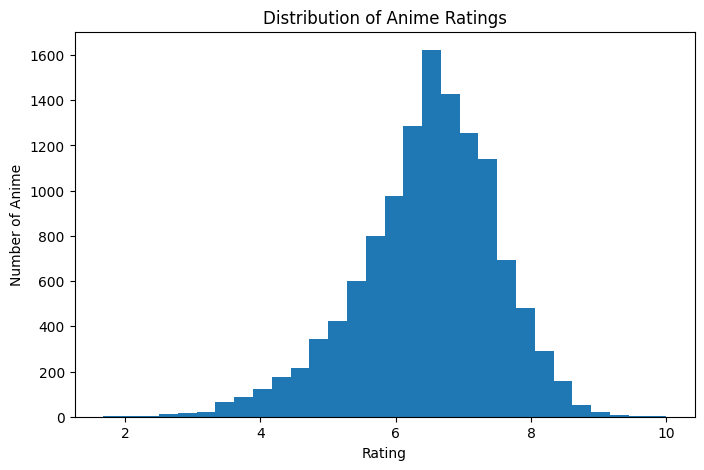

In [4]:
plt.figure(figsize=(8, 5))
plt.hist(data["rating"], bins=30)
plt.title("Distribution of Anime Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Anime")
plt.show()


### Anime type distribution

The `type` column describes the broadcast/release format of the anime.


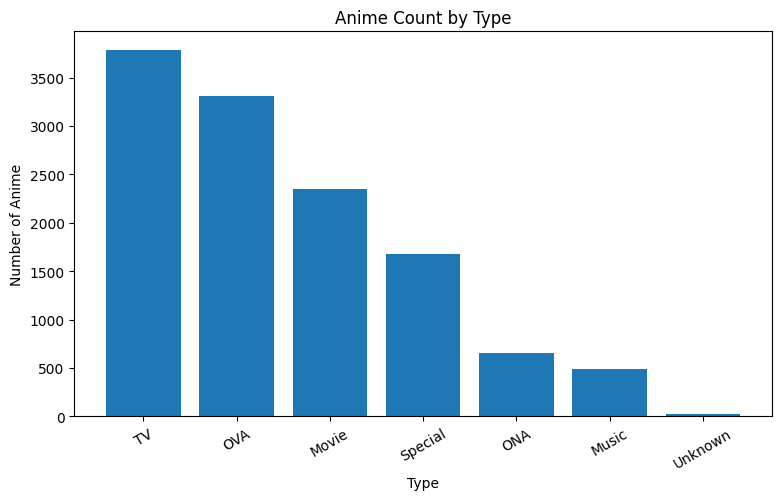

,Count
type,
TV,3787
OVA,3311
Movie,2348
Special,1676
ONA,659
Music,488
Unknown,25


In [5]:
type_counts = data["type"].value_counts()

plt.figure(figsize=(9, 5))
plt.bar(type_counts.index.astype(str), type_counts.values)
plt.title("Anime Count by Type")
plt.xlabel("Type")
plt.ylabel("Number of Anime")
plt.xticks(rotation=30)
plt.show()

display(type_counts.to_frame("Count"))


### Top genres

The genre field contains multiple genres in one text value, separated by commas. I split these values to understand which genres occur most frequently.


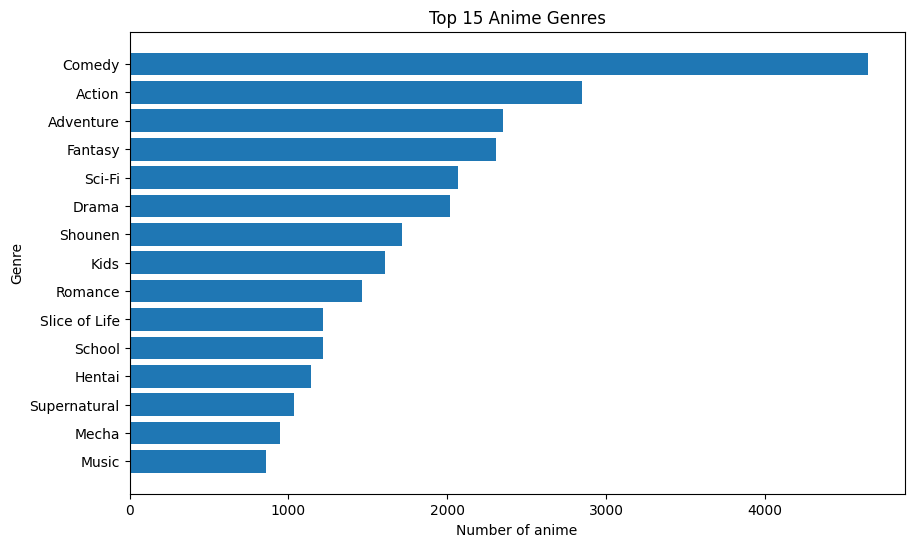

,Count
Comedy,4645
Action,2845
Adventure,2348
Fantasy,2309
Sci-Fi,2070
Drama,2016
Shounen,1712
Kids,1609
Romance,1464
Slice of Life,1220


In [6]:
genre_series = data["genre"].fillna("Unknown").str.split(", ")
all_genres = pd.Series([g for row in genre_series for g in row])
genre_counts = all_genres.value_counts().head(15)

plt.figure(figsize=(10, 6))
plt.barh(genre_counts.index[::-1], genre_counts.values[::-1])
plt.title("Top 15 Anime Genres")
plt.xlabel("Number of anime")
plt.ylabel("Genre")
plt.show()

display(genre_counts.to_frame("Count"))


## 5. Feature Extraction

For content-based recommendation, I create a numerical vector for every anime.

### Categorical features
- Genres → multi-hot encoding
- Type → one-hot encoding

### Numerical features
- Episodes
- Rating
- Members

The numerical features are standardized so that large-scale values such as `members` do not dominate the cosine similarity.

I do not use `anime_id` or the anime title as similarity features because they identify the item rather than describe its content.


In [7]:
# Multi-hot encode genres
mlb = MultiLabelBinarizer()
genre_matrix = mlb.fit_transform(data["genre"].str.split(", "))

genre_features = pd.DataFrame(
    genre_matrix,
    columns=[f"genre_{g}" for g in mlb.classes_],
    index=data.index
)

# One-hot encode anime type
type_features = pd.get_dummies(
    data["type"],
    prefix="type",
    dtype=float
)

# Standardize numerical features
num_cols = ["episodes_num", "rating", "members"]
scaler = StandardScaler()
num_matrix = scaler.fit_transform(data[num_cols])

num_features = pd.DataFrame(
    num_matrix,
    columns=[f"num_{c}" for c in num_cols],
    index=data.index
)

feature_matrix = pd.concat(
    [genre_features, type_features, num_features],
    axis=1
)

print("Genre features:", genre_features.shape[1])
print("Type features:", type_features.shape[1])
print("Numerical features:", num_features.shape[1])
print("Final feature matrix shape:", feature_matrix.shape)

display(feature_matrix.head())


Genre features: 44
Type features: 7
Numerical features: 3
Final feature matrix shape: (12294, 54)


,genre_Action,genre_Adventure,genre_Cars,genre_Comedy,genre_Dementia,genre_Demons,genre_Drama,genre_Ecchi,genre_Fantasy,genre_Game,...,type_Movie,type_Music,type_ONA,type_OVA,type_Special,type_TV,type_Unknown,num_episodes_num,num_rating,num_members
0,0,0,0,0,0,0,1,0,0,0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.239941,2.845534,3.330241
1,1,1,0,0,0,0,1,0,1,0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.122451,2.737388,14.148406
2,1,0,0,1,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.841323,2.727556,1.754713
3,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.257440,2.648904,11.957666
4,1,0,0,1,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.841323,2.639073,2.429742


## 6. Cosine Similarity

Cosine similarity measures the angle between two feature vectors:

**Cosine Similarity = (A · B) / (||A|| × ||B||)**

The value is generally between 0 and 1 for these non-negative content features, where a larger value means that the two anime have more similar feature representations.

I calculate the pairwise cosine similarity matrix once. This makes the recommendation function fast when many recommendations are requested.


In [8]:
similarity_matrix = cosine_similarity(feature_matrix)

print("Cosine similarity matrix shape:", similarity_matrix.shape)
print("Similarity matrix created successfully.")


Cosine similarity matrix shape: (12294, 12294)
Similarity matrix created successfully.


# 7. Recommendation Function

The function below accepts an anime title and returns the most similar anime.

The steps are:
1. Find the target anime in the dataset.
2. Get its similarity scores with all other anime.
3. Sort the scores from highest to lowest.
4. Remove the target anime itself.
5. Return the requested number of recommendations.
6. Optionally apply a similarity threshold.


In [9]:
def recommend_anime(title, n_recommendations=10, threshold=0.0):
    # Case-insensitive exact title match
    matches = data.index[
        data["name"].str.lower() == str(title).strip().lower()
    ].tolist()

    if not matches:
        # Helpful partial-search fallback
        partial = data[data["name"].str.contains(str(title), case=False, na=False)]
        if len(partial) == 0:
            raise ValueError("Anime title not found. Try a title from the dataset.")
        target_index = partial.index[0]
        print(f"Exact title not found. Using closest title match: {data.loc[target_index, 'name']}")
    else:
        target_index = matches[0]

    scores = similarity_matrix[target_index]

    # Rank all anime by similarity
    ranked_indices = np.argsort(scores)[::-1]

    recommendations = []
    for idx in ranked_indices:
        if idx == target_index:
            continue

        score = scores[idx]

        if score < threshold:
            break

        recommendations.append({
            "Anime": data.loc[idx, "name"],
            "Type": data.loc[idx, "type"],
            "Genre": data.loc[idx, "genre"],
            "Rating": data.loc[idx, "rating"],
            "Members": data.loc[idx, "members"],
            "Cosine Similarity": round(float(score), 4)
        })

        if len(recommendations) >= n_recommendations:
            break

    return pd.DataFrame(recommendations)


## 8. Example Recommendation

The code below automatically takes the first available anime title, so the notebook remains reproducible even if the dataset version changes slightly.


In [10]:
example_title = data.iloc[0]["name"]

print("Target anime:", example_title)
recommendations = recommend_anime(
    example_title,
    n_recommendations=10,
    threshold=0.0
)

display(recommendations)


Target anime: Kimi no Na wa.


,Anime,Type,Genre,Rating,Members,Cosine Similarity
0,Hotarubi no Mori e,Movie,"Drama, Romance, Shoujo, Supernatural",8.61,197439,0.9463
1,Suzumiya Haruhi no Shoushitsu,Movie,"Comedy, Mystery, Romance, School, Sci-Fi, Supe...",8.81,240297,0.9122
2,Hotaru no Haka,Movie,"Drama, Historical",8.58,174878,0.9006
3,"Clannad: After Story - Mou Hitotsu no Sekai, K...",Special,"Drama, Romance, School",8.02,138364,0.8921
4,Kotonoha no Niwa,Movie,"Drama, Psychological, Romance, Slice of Life",8.35,189741,0.8902
5,Yahari Ore no Seishun Love Comedy wa Machigatt...,TV,"Comedy, Drama, Romance, School",8.31,222994,0.8864
6,Howl no Ugoku Shiro,Movie,"Adventure, Drama, Fantasy, Romance",8.74,333186,0.8832
7,Toki wo Kakeru Shoujo,Movie,"Adventure, Drama, Romance, Sci-Fi",8.44,289206,0.8814
8,"Clannad: Mou Hitotsu no Sekai, Tomoyo-hen",Special,"Drama, Romance, School, Slice of Life",8.14,160423,0.8733
9,Koe no Katachi,Movie,"Drama, School, Shounen",9.05,102733,0.8727


## 9. Try a Different Anime

To recommend for another anime, replace target_title with any title from the dataset.

If the exact title is not found, the function also attempts a partial title match.


In [11]:
# Example using the second anime in the dataset
target_title = data.iloc[1]["name"]

print("Target anime:", target_title)
display(recommend_anime(target_title, n_recommendations=10))


Target anime: Fullmetal Alchemist: Brotherhood


,Anime,Type,Genre,Rating,Members,Cosine Similarity
0,Fullmetal Alchemist,TV,"Action, Adventure, Comedy, Drama, Fantasy, Mag...",8.33,600384,0.9939
1,Shingeki no Kyojin,TV,"Action, Drama, Fantasy, Shounen, Super Power",8.54,896229,0.9873
2,Akame ga Kill!,TV,"Action, Adventure, Fantasy",7.84,492133,0.9852
3,Soul Eater,TV,"Action, Adventure, Comedy, Fantasy, Shounen, S...",8.08,580184,0.9820
4,Sword Art Online,TV,"Action, Adventure, Fantasy, Game, Romance",7.83,893100,0.9795
5,Noragami,TV,"Action, Adventure, Shounen, Supernatural",8.17,515378,0.9794
6,Ao no Exorcist,TV,"Action, Demons, Fantasy, Shounen, Supernatural",7.92,583823,0.9781
7,Angel Beats!,TV,"Action, Comedy, Drama, School, Supernatural",8.39,717796,0.9759
8,Code Geass: Hangyaku no Lelouch,TV,"Action, Mecha, Military, School, Sci-Fi, Super...",8.83,715151,0.9753
9,Steins;Gate,TV,"Sci-Fi, Thriller",9.17,673572,0.9753


# 10. Experiment with Similarity Thresholds

A threshold can be used to control how similar an anime must be before it is recommended.

- Lower threshold → more recommendations, but some may be weak matches.
- Higher threshold → fewer recommendations, but they should be more similar.

I test several thresholds and count how many recommendations are available for the same target anime.


In [12]:
thresholds = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80]

threshold_results = []

for threshold in thresholds:
    recs = recommend_anime(
        example_title,
        n_recommendations=1000,
        threshold=threshold
    )

    threshold_results.append({
        "Threshold": threshold,
        "Number of Recommendations": len(recs),
        "Highest Similarity": recs["Cosine Similarity"].max() if len(recs) else np.nan,
        "Lowest Similarity Included": recs["Cosine Similarity"].min() if len(recs) else np.nan
    })

threshold_df = pd.DataFrame(threshold_results)
display(threshold_df.round(4))


,Threshold,Number of Recommendations,Highest Similarity,Lowest Similarity Included
0,0.1,1000,0.9463,0.5071
1,0.2,1000,0.9463,0.5071
2,0.3,1000,0.9463,0.5071
3,0.4,1000,0.9463,0.5071
4,0.5,1000,0.9463,0.5071
5,0.6,704,0.9463,0.6001
6,0.7,424,0.9463,0.7001
7,0.8,121,0.9463,0.8001


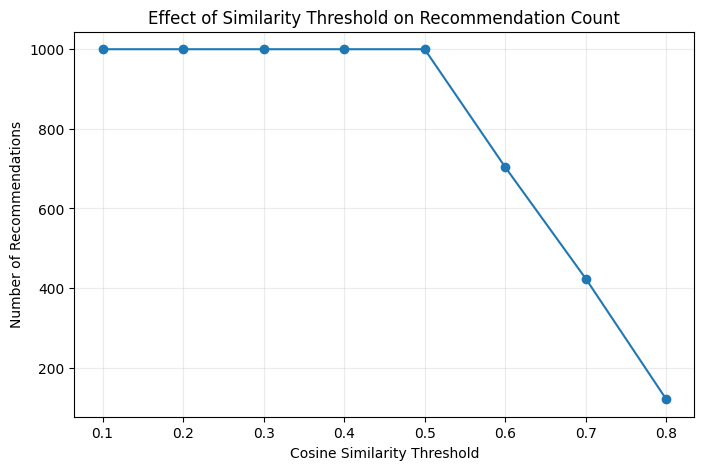

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(
    threshold_df["Threshold"],
    threshold_df["Number of Recommendations"],
    marker="o"
)
plt.title("Effect of Similarity Threshold on Recommendation Count")
plt.xlabel("Cosine Similarity Threshold")
plt.ylabel("Number of Recommendations")
plt.grid(alpha=0.25)
plt.show()


## 11. Compare Recommendation Quality at Different Thresholds

The exact threshold should depend on the application.
 I inspect the recommendations at a few thresholds. A threshold that is too low may return many loosely related anime, while a threshold that is too high may return very few results.


In [14]:
for threshold in [0.2, 0.4, 0.6]:
    print("\n" + "="*70)
    print(f"Threshold = {threshold}")
    print("="*70)
    display(
        recommend_anime(
            example_title,
            n_recommendations=5,
            threshold=threshold
        )
    )



Threshold = 0.2


,Anime,Type,Genre,Rating,Members,Cosine Similarity
0,Hotarubi no Mori e,Movie,"Drama, Romance, Shoujo, Supernatural",8.61,197439,0.9463
1,Suzumiya Haruhi no Shoushitsu,Movie,"Comedy, Mystery, Romance, School, Sci-Fi, Supe...",8.81,240297,0.9122
2,Hotaru no Haka,Movie,"Drama, Historical",8.58,174878,0.9006
3,"Clannad: After Story - Mou Hitotsu no Sekai, K...",Special,"Drama, Romance, School",8.02,138364,0.8921
4,Kotonoha no Niwa,Movie,"Drama, Psychological, Romance, Slice of Life",8.35,189741,0.8902



Threshold = 0.4


,Anime,Type,Genre,Rating,Members,Cosine Similarity
0,Hotarubi no Mori e,Movie,"Drama, Romance, Shoujo, Supernatural",8.61,197439,0.9463
1,Suzumiya Haruhi no Shoushitsu,Movie,"Comedy, Mystery, Romance, School, Sci-Fi, Supe...",8.81,240297,0.9122
2,Hotaru no Haka,Movie,"Drama, Historical",8.58,174878,0.9006
3,"Clannad: After Story - Mou Hitotsu no Sekai, K...",Special,"Drama, Romance, School",8.02,138364,0.8921
4,Kotonoha no Niwa,Movie,"Drama, Psychological, Romance, Slice of Life",8.35,189741,0.8902



Threshold = 0.6


,Anime,Type,Genre,Rating,Members,Cosine Similarity
0,Hotarubi no Mori e,Movie,"Drama, Romance, Shoujo, Supernatural",8.61,197439,0.9463
1,Suzumiya Haruhi no Shoushitsu,Movie,"Comedy, Mystery, Romance, School, Sci-Fi, Supe...",8.81,240297,0.9122
2,Hotaru no Haka,Movie,"Drama, Historical",8.58,174878,0.9006
3,"Clannad: After Story - Mou Hitotsu no Sekai, K...",Special,"Drama, Romance, School",8.02,138364,0.8921
4,Kotonoha no Niwa,Movie,"Drama, Psychological, Romance, Slice of Life",8.35,189741,0.8902


# 12. Analyze the Recommendation System

### Strengths

1. **Simple and interpretable** – cosine similarity directly measures how close two anime feature vectors are.
2. **No user-history requirement** – recommendations can be produced even for a new user.
3. **Uses anime content** – genre and type make the recommendations understandable.
4. **Adjustable threshold** – the threshold controls how strict the similarity requirement is.

### Limitations

1. **Cold-start for new anime** – the system needs genre/type/metadata for a new item.
2. **No personal preference** – this system recommends items similar to the selected anime, not necessarily items a particular user will like.
3. **Feature quality matters** – weak metadata produces weak recommendations.
4. **Ratings are not user-specific** – average rating does not reveal which users liked which anime.
5. **Genre overlap can dominate** – anime sharing many genres may receive high similarity even when their actual story or style is different.

### Areas for improvement

- Add user-anime interaction data.
- Use collaborative filtering.
- Combine content-based and collaborative filtering into a hybrid system.
- Add richer text features from synopsis or descriptions.
- Include popularity carefully so that highly popular anime do not dominate every recommendation.
- Evaluate recommendations with user feedback and ranking metrics such as Precision@K, Recall@K or NDCG when ground-truth user interactions are available.


# 13. Interview Question 1

## Can you explain the difference between user-based and item-based collaborative filtering?

### User-based collaborative filtering

User-based collaborative filtering finds users who have similar behaviour or preferences.

For example:
- User A and User B both rated many anime similarly.
- If User B likes another anime that User A has not watched, that anime can be recommended to User A.

The basic idea is:

**Similar users  recommend items liked by similar users.**

### Item-based collaborative filtering

Item-based collaborative filtering finds items that are frequently liked or interacted with by the same users.

For example:
- Many users who watched Anime A also watched Anime B.
- Anime B can therefore be recommended when someone watches Anime A.

The basic idea is:

**Similar items  recommend items similar to the user's existing items.**

The system in this assignment is **content-based**, not collaborative filtering, because it uses anime attributes such as genres, type, episodes and ratings rather than a user-item interaction matrix.


# 14. Interview Question 2

## What is collaborative filtering, and how does it work?

Collaborative filtering is a recommendation approach that uses the behaviour or preferences of many users to recommend items.

Instead of depending mainly on item descriptions, it learns from interactions such as:
- ratings,
- likes,
- purchases,
- views,
- watches,
- clicks.

### Basic process

1. Create a user-item interaction matrix.
2. Measure similarity between users or items.
3. Identify similar users/items.
4. Use those similarities to predict which items a user may prefer.
5. Recommend the highest-scoring unseen items.

There are two common approaches:

### User-based collaborative filtering
Find users with similar behaviour and recommend what those users liked.

### Item-based collaborative filtering
Find items that behave similarly across users and recommend items related to what the user has already interacted with.

### Difference from this assignment

This notebook implements **content-based filtering with cosine similarity**. It does not have individual user-rating histories, so it cannot learn personal user-user or item-item collaborative relationships from a user-item matrix.


# 16. Final Conclusion

A content-based anime recommendation system was developed using cosine similarity.

The main workflow was:

1. Load and inspect the anime dataset.
2. Handle missing values.
3. Clean anime titles.
4. Convert genres into multi-hot numerical features.
5. One-hot encode anime type.
6. Standardize numerical features.
7. Create the final feature matrix.
8. Calculate cosine similarity.
9. Build a recommendation function.
10. Experiment with different similarity thresholds.
11. Analyze strengths, limitations and possible improvements.

